# Noise estimation

In [2]:
noisy_data_path = "/srv/defectDetectionDataset/multiclassClassification/noisy"
clean_data_path = "/srv/defectDetectionDataset/multiclassClassification/full_clean"

artifacts_path = "/home/lukasb/Documents/NoisyLabelDefectDetection/notebooks/data_cleaning/artifacts/noise_estimation"

In [3]:
import os
import pandas as pd

In [4]:
os.makedirs(artifacts_path, exist_ok=True)

In [5]:
from hashlib import md5
from PIL import Image

noisy_images = []

extensions = [".png", ".jpg", ".jpeg"]

for dirpath, dirnames, filenames in os.walk(noisy_data_path):
    for filename in filenames:
        if any(filename.endswith(ext) for ext in extensions):
            file_path = os.path.join(dirpath, filename)
            label = os.path.basename(dirpath)
            img = Image.open(file_path)
            image_id = md5(img.tobytes()).hexdigest()
            noisy_images.append({"image_id": image_id, "file_path": file_path, "label": label})


clean_images = []

for dirpath, dirnames, filenames in os.walk(clean_data_path):
    for filename in filenames:
        if any(filename.endswith(ext) for ext in extensions):
            file_path = os.path.join(dirpath, filename)
            label = os.path.basename(dirpath)
            img = Image.open(file_path)
            image_id = md5(img.tobytes()).hexdigest()
            clean_images.append({"image_id": image_id, "file_path": file_path, "label": label})

noisy_df = pd.DataFrame(noisy_images)
clean_df = pd.DataFrame(clean_images)

In [9]:
noisy_labels = noisy_df[["image_id", "label"]]
clean_labels = clean_df[["image_id", "label"]]

## Confusion matrix

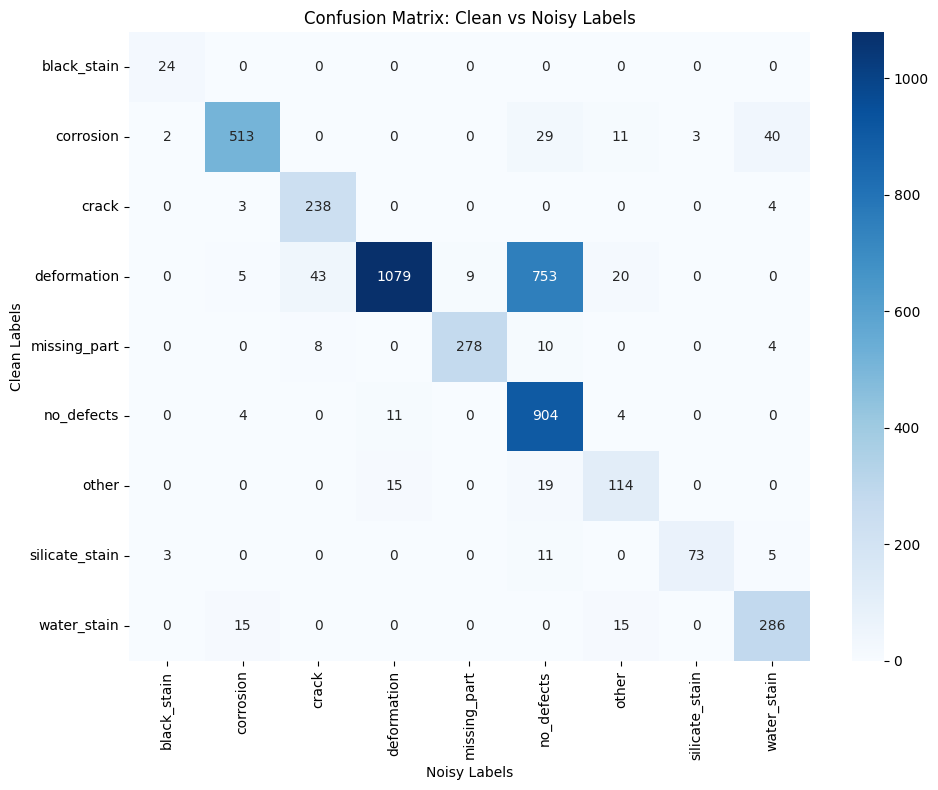

Confusion Matrix saved to /home/lukasb/Documents/NoisyLabelDefectDetection/notebooks/data_cleaning/artifacts/noise_estimation/confusion_matrix.png

Total images matched: 4555


In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Merge noisy and clean labels on image_id
merged_labels = noisy_labels.merge(clean_labels, on='image_id', suffixes=('_noisy', '_clean'))

# Create confusion matrix
import matplotlib.pyplot as plt

# Get the confusion matrix
cm = confusion_matrix(merged_labels['label_clean'], merged_labels['label_noisy'])

# Get unique labels
labels = sorted(merged_labels['label_clean'].unique())

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Noisy Labels')
plt.ylabel('Clean Labels')
plt.title('Confusion Matrix: Clean vs Noisy Labels')
plt.tight_layout()
plt.savefig(os.path.join(artifacts_path, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"Confusion Matrix saved to {os.path.join(artifacts_path, 'confusion_matrix.png')}")
print(f"\nTotal images matched: {len(merged_labels)}")

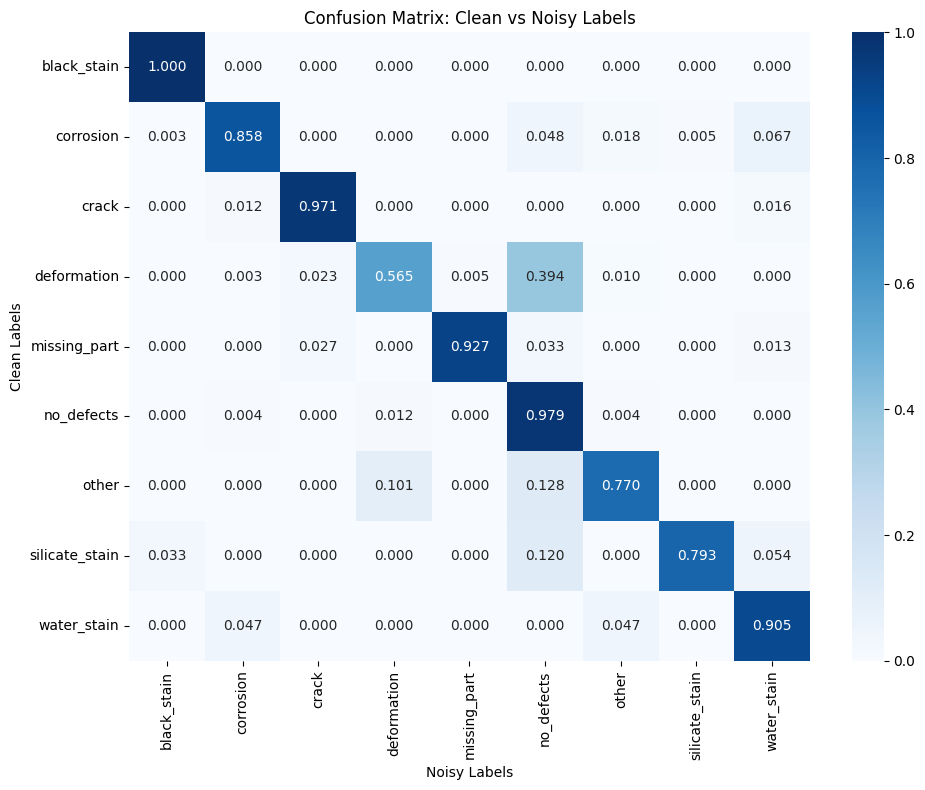

Confusion Matrix saved to /home/lukasb/Documents/NoisyLabelDefectDetection/notebooks/data_cleaning/artifacts/noise_estimation/confusion_matrix_normalized.png

Total images matched: 4555


In [17]:
# Get the confusion matrix
cm_n = confusion_matrix(merged_labels['label_clean'], merged_labels['label_noisy'], normalize='true')

# Get unique labels
labels = sorted(merged_labels['label_clean'].unique())

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_n, annot=True, fmt='.3f', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Noisy Labels')
plt.ylabel('Clean Labels')
plt.title('Confusion Matrix: Clean vs Noisy Labels')
plt.tight_layout()
plt.savefig(os.path.join(artifacts_path, 'confusion_matrix_normalized.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"Confusion Matrix saved to {os.path.join(artifacts_path, 'confusion_matrix_normalized.png')}")
print(f"\nTotal images matched: {len(merged_labels)}")

In [19]:
import torch
from pathlib import Path
from datetime import datetime

def save_noise_matrix(path: str, T: torch.Tensor, class_names=None, extra=None):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    payload = {
        "T": T.detach().float().cpu(),          # [C, C], row-stochastic
        "convention": "T[i,j]=P(y_noisy=j | y_clean=i)",
        "normalized": "rowsum=1",
        "class_names": class_names,             # list[str] in the exact index order
        "created_at": datetime.now().isoformat(),
        "extra": extra or {},                   # anything: dataset, split, estimator settings, seed, etc.
    }
    torch.save(payload, path)

save_noise_matrix(os.path.join(artifacts_path, 'noise_matrix.pt'), torch.tensor(cm_n), class_names=labels)